# 05 · Anomaly Detection

**Goal:** surface behaviour that breaks its own pattern, so that someone investigates it. Code:
`machine_learning/anomaly_detection/detect.py`.

| Detector | What it finds | Method |
|---|---|---|
| Daily revenue and orders | Unexpected drops and unusual transaction spikes | Each day relative to its trailing 28-day level, compared with the same weekday's typical ratio (robust z ≥ 3.5 **and** ≥ 30% deviation) |
| Daily profile | Days with an odd *combination* of metrics | Isolation Forest (1% contamination) |
| Products | Products selling far outside their own history | Poisson test, last 28 days vs the previous 84 (p < 0.001) |
| Customers | Extreme purchasing profiles | Isolation Forest (0.1% contamination) |

Every anomaly is stored with a plain-language explanation built from its numbers.

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))   # project root
warnings.filterwarnings("ignore", category=UserWarning)

import json
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import Markdown, display

from nexus_nb import AXIS, GRID, INK, MUTED_FILL, SEQUENTIAL_BLUE, SERIES, brl, query

period = query("SELECT * FROM analytics.v_reporting_period").iloc[0]

an = query("SELECT * FROM analytics.v_anomalies")
an.groupby(["entity_type", "method", "direction"]).size().rename("anomalies").to_frame()

anomalies
entity_type method                 direction           
customer    isolation_forest       mixed             95
day         isolation_forest       mixed              6
            robust_z_same_weekday  down              17
                                   up                24
product     poisson_vs_own_history down              12
                                   up                13

## 1. Days that broke the pattern

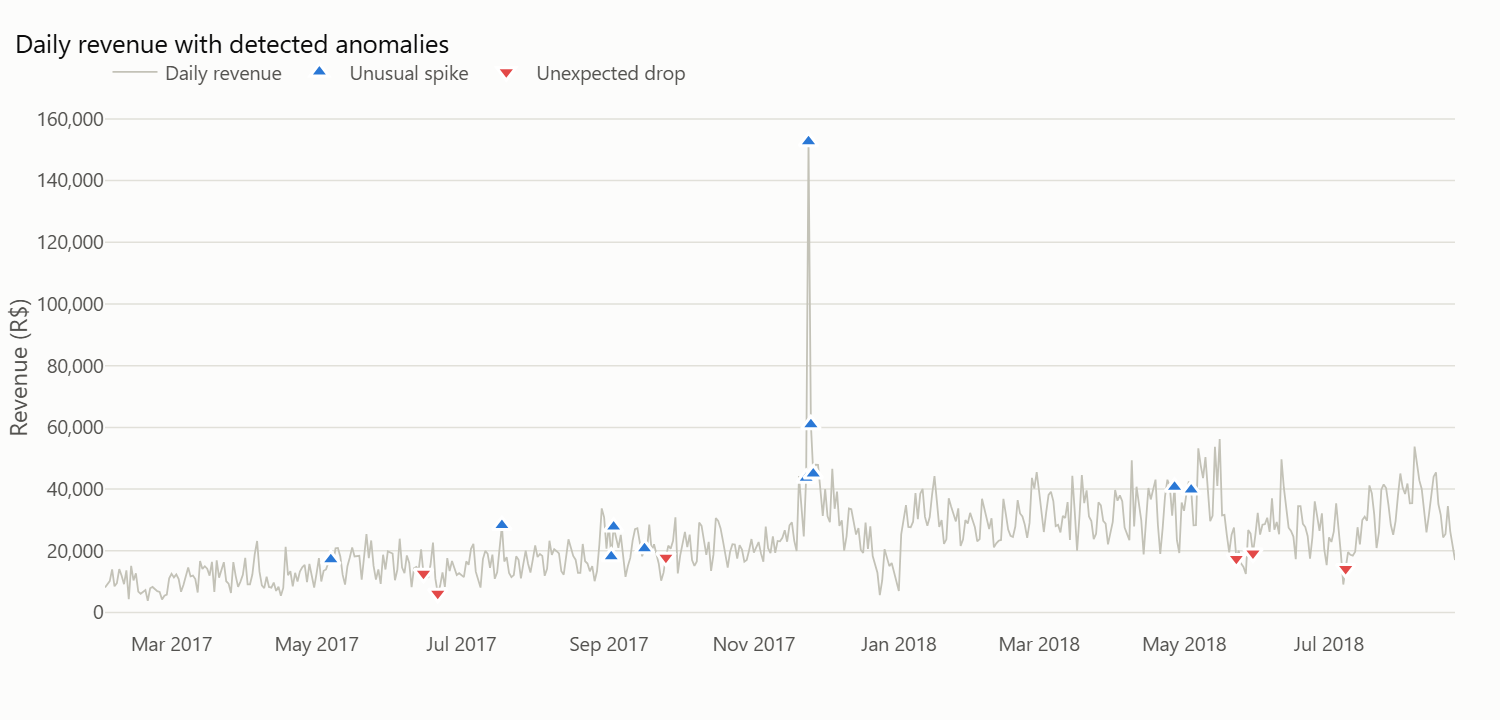

,period_start,metric,direction,score,description
28,2017-11-24,orders,up,37.53,"Orders on Fri 24 Nov 2017 (Black Friday) were 1,166, +657% vs the 154 expected for a Friday at the current sales level (robust z = +37.5)."
12,2017-11-24,revenue,up,30.05,"Revenue on Fri 24 Nov 2017 (Black Friday) was R$ 152,654, +523% vs the R$ 24,512 expected for a Friday at the current sales level (robust z = +30.1)."
29,2017-11-25,orders,up,20.80,"Orders on Sat 25 Nov 2017 were 499, +218% vs the 157 expected for a Saturday at the current sales level (robust z = +20.8)."
17,2018-05-23,revenue,down,14.18,"Revenue on Wed 23 May 2018 was R$ 17,501, -61% vs the R$ 44,893 expected for a Wednesday at the current sales level (robust z = -14.2)."
18,2018-05-30,revenue,down,12.30,"Revenue on Wed 30 May 2018 was R$ 19,214, -53% vs the R$ 40,821 expected for a Wednesday at the current sales level (robust z = -12.3)."
8,2017-09-03,revenue,up,10.34,"Revenue on Sun 03 Sep 2017 was R$ 27,741, +90% vs the R$ 14,608 expected for a Sunday at the current sales level (robust z = +10.3)."
7,2017-09-02,revenue,up,10.00,"Revenue on Sat 02 Sep 2017 was R$ 18,129, +31% vs the R$ 13,793 expected for a Saturday at the current sales level (robust z = +10.0)."
3,2017-05-07,revenue,up,8.12,"Revenue on Sun 07 May 2017 was R$ 17,168, +120% vs the R$ 7,797 expected for a Sunday at the current sales level (robust z = +8.1)."
26,2017-11-16,orders,up,8.00,"Orders on Thu 16 Nov 2017 were 224, +53% vs the 147 expected for a Thursday at the current sales level (robust z = +8.0)."
13,2017-11-25,revenue,up,7.50,"Revenue on Sat 25 Nov 2017 was R$ 60,923, +180% vs the R$ 21,775 expected for a Saturday at the current sales level (robust z = +7.5)."


In [2]:
daily = query("SELECT day, revenue FROM analytics.v_sales_forecast WHERE kind = 'actual' ORDER BY day")
daily["day"] = pd.to_datetime(daily["day"])
rev = an[(an["metric"] == "revenue") & (an["entity_type"] == "day")].copy()
rev["day"] = pd.to_datetime(rev["period_start"])

fig = go.Figure()
fig.add_scatter(x=daily["day"], y=daily["revenue"], mode="lines", name="Daily revenue",
                line=dict(color=MUTED_FILL, width=1.2), hovertemplate="%{x|%a %d %b %Y}: R$ %{y:,.0f}<extra></extra>")
for direction, color, symbol, name in [("up", SERIES[0], "triangle-up", "Unusual spike"),
                                       ("down", SERIES[7], "triangle-down", "Unexpected drop")]:
    part = rev[rev["direction"] == direction]
    fig.add_scatter(x=part["day"], y=part["observed"], mode="markers", name=name,
                    marker=dict(color=color, size=11, symbol=symbol, line=dict(width=2, color="white")),
                    customdata=part["description"], hovertemplate="%{customdata}<extra></extra>")
fig.update_layout(title="Daily revenue with detected anomalies", yaxis=dict(title="Revenue (R$)", tickformat=",.0f"))
fig.show()

pd.set_option("display.max_colwidth", None)
an[an["method"] == "robust_z_same_weekday"].nlargest(10, "score")[["period_start", "metric", "direction", "score", "description"]]

In [3]:
an[(an["entity_type"] == "day") & (an["method"] == "isolation_forest")].sort_values("score", ascending=False)[
    ["period_start", "score", "description"]]

,period_start,score,description
44,2017-11-24,0.67,Unusual combination of metrics on Fri 24 Nov 2017 (Black Friday): orders vs trailing 28-day median 7.26 (typical 1.04); revenue vs trailing 28-day median 6.63 (typical 1.04).
43,2017-04-18,0.66,Unusual combination of metrics on Tue 18 Apr 2017: average order value 299.81 (typical 134.77); revenue vs trailing 28-day median 2.16 (typical 1.04).
45,2017-11-25,0.62,Unusual combination of metrics on Sat 25 Nov 2017: orders vs trailing 28-day median 2.98 (typical 1.04); revenue vs trailing 28-day median 2.63 (typical 1.04).
42,2017-04-01,0.62,Unusual combination of metrics on Sat 01 Apr 2017: average order value 264.14 (typical 134.77); items per order 1.03 (typical 1.13).
46,2018-05-26,0.61,Unusual combination of metrics on Sat 26 May 2018: share of first-time customers 0.92 (typical 0.97); share of boleto payments 0.10 (typical 0.20).
41,2017-03-18,0.61,Unusual combination of metrics on Sat 18 Mar 2017: average order value 225.12 (typical 134.77); share of first-time customers 1.00 (typical 0.97).


## 2. Products outside their historical pattern

,entity_label,direction,observed,expected,score,description
59,e7cc48a9,up,87.00,2.00,106.99,Product e7cc48a9 (telephony) sold 87 units in the last 28 days vs 2.0 expected from its previous 84 days (+4250%; Poisson p = 1.0e-107).
47,53b36df6,down,2.00,35.00,12.39,Product 53b36df6 (watches_gifts) sold 2 units in the last 28 days vs 35.0 expected from its previous 84 days (-94%; Poisson p = 4.1e-13).
48,d285360f,down,0.00,23.33,10.13,Product d285360f (watches_gifts) sold 0 units in the last 28 days vs 23.3 expected from its previous 84 days (-100%; Poisson p = 7.4e-11).
49,aca2eb7d,down,3.00,28.67,8.81,Product aca2eb7d (furniture_decor) sold 3 units in the last 28 days vs 28.7 expected from its previous 84 days (-90%; Poisson p = 1.6e-09).
50,89b121be,down,0.00,16.67,7.24,Product 89b121be (computers_accessories) sold 0 units in the last 28 days vs 16.7 expected from its previous 84 days (-100%; Poisson p = 5.8e-08).
60,9fe172fa,up,14.00,2.33,6.73,Product 9fe172fa (fashion_bags_accessories) sold 14 units in the last 28 days vs 2.3 expected from its previous 84 days (+500%; Poisson p = 1.9e-07).
51,3dd2a171,down,6.00,28.33,6.35,Product 3dd2a171 (computers_accessories) sold 6 units in the last 28 days vs 28.3 expected from its previous 84 days (-79%; Poisson p = 4.5e-07).
62,c20a3f59,up,16.00,3.67,5.78,Product c20a3f59 (housewares) sold 16 units in the last 28 days vs 3.7 expected from its previous 84 days (+336%; Poisson p = 1.7e-06).
61,af2d506f,up,16.00,3.67,5.78,Product af2d506f (baby) sold 16 units in the last 28 days vs 3.7 expected from its previous 84 days (+336%; Poisson p = 1.7e-06).
63,bb50f2e2,up,33.00,13.00,5.62,Product bb50f2e2 (health_beauty) sold 33 units in the last 28 days vs 13.0 expected from its previous 84 days (+154%; Poisson p = 2.4e-06).


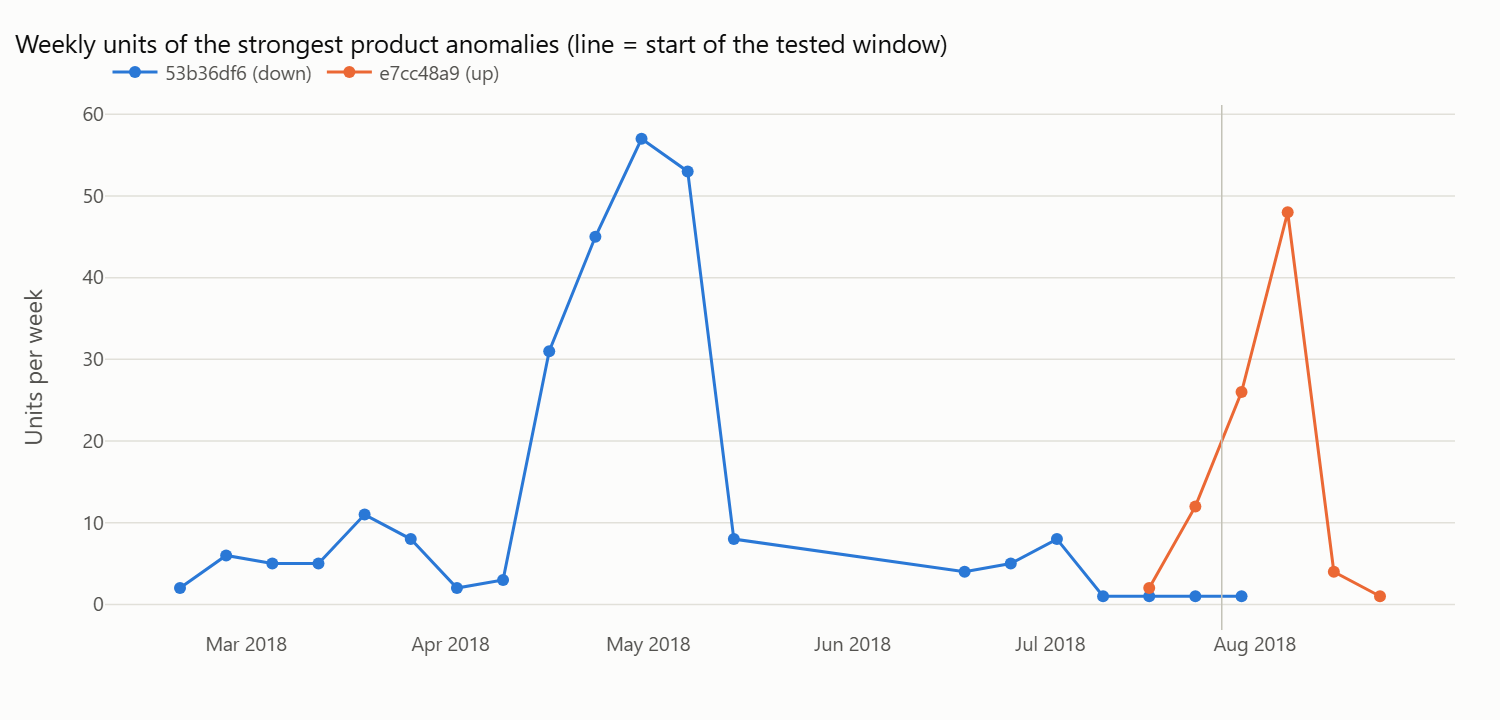

In [4]:
prod = an[an["entity_type"] == "product"].sort_values("score", ascending=False)
display(prod[["entity_label", "direction", "observed", "expected", "score", "description"]].head(12))

# Weekly units of the strongest drop and the strongest spike, to see what the test reacted to.
examples = [prod[prod["direction"] == d].iloc[0] for d in ("down", "up") if (prod["direction"] == d).any()]
weekly = query("""
    SELECT product_key, date_trunc('week', purchase_date)::date AS week, count(*) AS units
    FROM analytics.v_sales_items
    WHERE product_key = ANY(:keys)
      AND purchase_date >= (SELECT reference_date - 196 FROM analytics.v_reporting_period)
      AND purchase_date <  (SELECT reference_date FROM analytics.v_reporting_period)
    GROUP BY 1, 2 ORDER BY 2
""", keys=[int(e["entity_key"]) for e in examples])
fig = go.Figure()
for i, e in enumerate(examples):
    w = weekly[weekly["product_key"] == e["entity_key"]]
    fig.add_scatter(x=w["week"], y=w["units"], mode="lines+markers", name=f"{e['entity_label']} ({e['direction']})",
                    line=dict(color=SERIES[i], width=2), marker=dict(size=8))
fig.add_vline(x=pd.Timestamp(an.loc[an["entity_type"] == "product", "period_start"].iloc[0]), line=dict(color=AXIS, width=1))
fig.update_layout(title="Weekly units of the strongest product anomalies (line = start of the tested window)",
                  yaxis_title="Units per week")
fig.show()

## 3. Customers with unusual purchasing profiles

In [5]:
an[an["entity_type"] == "customer"].nlargest(10, "score")[["entity_label", "period_start", "period_end", "observed", "description"]]

,entity_label,period_start,period_end,observed,description
164,c8460e42,2018-08-07,2018-08-08,"4,080.00","Unusual purchasing profile: lifetime spend R$ 4,080.00 (higher than 99.99% of customers); orders 4 (higher than 99.95% of customers)."
133,5a494c64,2018-03-08,2018-03-08,"1,065.00","Unusual purchasing profile: items per order 5.5 (higher than 99.76% of customers); lifetime spend R$ 1,065.00 (higher than 99.08% of customers)."
161,4644f1b1,2018-03-16,2018-03-16,900.00,Unusual purchasing profile: items per order 6.0 (higher than 99.76% of customers); orders on a single day 2 (higher than 99.06% of customers).
165,33176de6,2018-02-22,2018-06-04,"1,021.50",Unusual purchasing profile: orders 3 (higher than 99.75% of customers); items per order 3.7 (higher than 99.08% of customers).
86,d97b3cfb,2017-10-17,2017-10-17,878.08,Unusual purchasing profile: items per order 6.5 (higher than 99.94% of customers); orders on a single day 2 (higher than 99.06% of customers).
148,c169c993,2017-05-09,2017-05-09,"1,511.20","Unusual purchasing profile: lifetime spend R$ 1,511.20 (higher than 99.59% of customers); items per order 4.0 (higher than 99.09% of customers)."
97,3ec83b54,2018-02-27,2018-02-27,"1,349.46","Unusual purchasing profile: items per order 4.5 (higher than 99.56% of customers); lifetime spend R$ 1,349.46 (higher than 99.46% of customers)."
118,da122df9,2017-04-01,2017-04-01,"7,388.00","Unusual purchasing profile: lifetime spend R$ 7,388.00 (higher than 100.00% of customers); average order R$ 3,694.00 (higher than 99.98% of customers)."
132,d77aa958,2017-08-29,2017-08-29,"2,400.00","Unusual purchasing profile: installments 18 (higher than 99.93% of customers); lifetime spend R$ 2,400.00 (higher than 99.91% of customers)."
85,a3dc27d8,2018-02-23,2018-04-13,464.28,Unusual purchasing profile: orders 3 (higher than 99.75% of customers); items per order 3.7 (higher than 99.08% of customers).


## 4. Findings

Generated from the results above.

In [6]:
spikes = an[(an["method"] == "robust_z_same_weekday")]
top = spikes.nlargest(1, "score").iloc[0]
drops = spikes[spikes["direction"] == "down"].nlargest(1, "score").iloc[0]
n_days = spikes["period_start"].nunique()
display(Markdown(f"""
1. **{n_days} days** broke their weekday pattern on revenue or orders. The strongest: {top['description']}
2. **The largest unexpected drop:** {drops['description']} A drop like this in production would trigger a check of site
   availability, payment processing or data ingestion for that day.
3. **Products:** {int((prod['direction'] == 'down').sum())} products with a solid history nearly stopped selling, and
   {int((prod['direction'] == 'up').sum())} surged far above their pattern. These are candidates for stock-out, listing or pricing checks.
4. **Customers:** {int((an['entity_type'] == 'customer').sum())} customers ({an[an['entity_type'] == 'customer'].shape[0] / query('SELECT count(*) AS n FROM analytics.v_customer_summary')['n'].iloc[0]:.2%} of the base) have
   extreme profiles (very high spend, many orders on one day, unusually large baskets). They are worth reviewing
   as either high-value accounts or possible resellers or fraud.
5. Anomalies are **signals for investigation, not conclusions**. Each one carries the numbers behind it.
"""))


1. **32 days** broke their weekday pattern on revenue or orders. The strongest: Orders on Fri 24 Nov 2017 (Black Friday) were 1,166, +657% vs the 154 expected for a Friday at the current sales level (robust z = +37.5).
2. **The largest unexpected drop:** Revenue on Wed 23 May 2018 was R$ 17,501, -61% vs the R$ 44,893 expected for a Wednesday at the current sales level (robust z = -14.2). A drop like this in production would trigger a check of site
   availability, payment processing or data ingestion for that day.
3. **Products:** 12 products with a solid history nearly stopped selling, and
   13 surged far above their pattern. These are candidates for stock-out, listing or pricing checks.
4. **Customers:** 95 customers (0.10% of the base) have
   extreme profiles (very high spend, many orders on one day, unusually large baskets). They are worth reviewing
   as either high-value accounts or possible resellers or fraud.
5. Anomalies are **signals for investigation, not conclusions**. Each one carries the numbers behind it.
